# Kaggle Space Titanic prediction quest  by 김민수

기본 세팅 : 라이브러리 호출 및 데이터 로드

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
from os.path import join

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

data_dir = os.path.join(os.getenv('HOME'), 'work/kaggle_kakr_housing/space_titanic')

train_data_path = os.path.join(data_dir, 'train.csv')
test_data_path = os.path.join(data_dir, 'test.csv')  

Train 데이터 null 여부 체크

<Axes: >

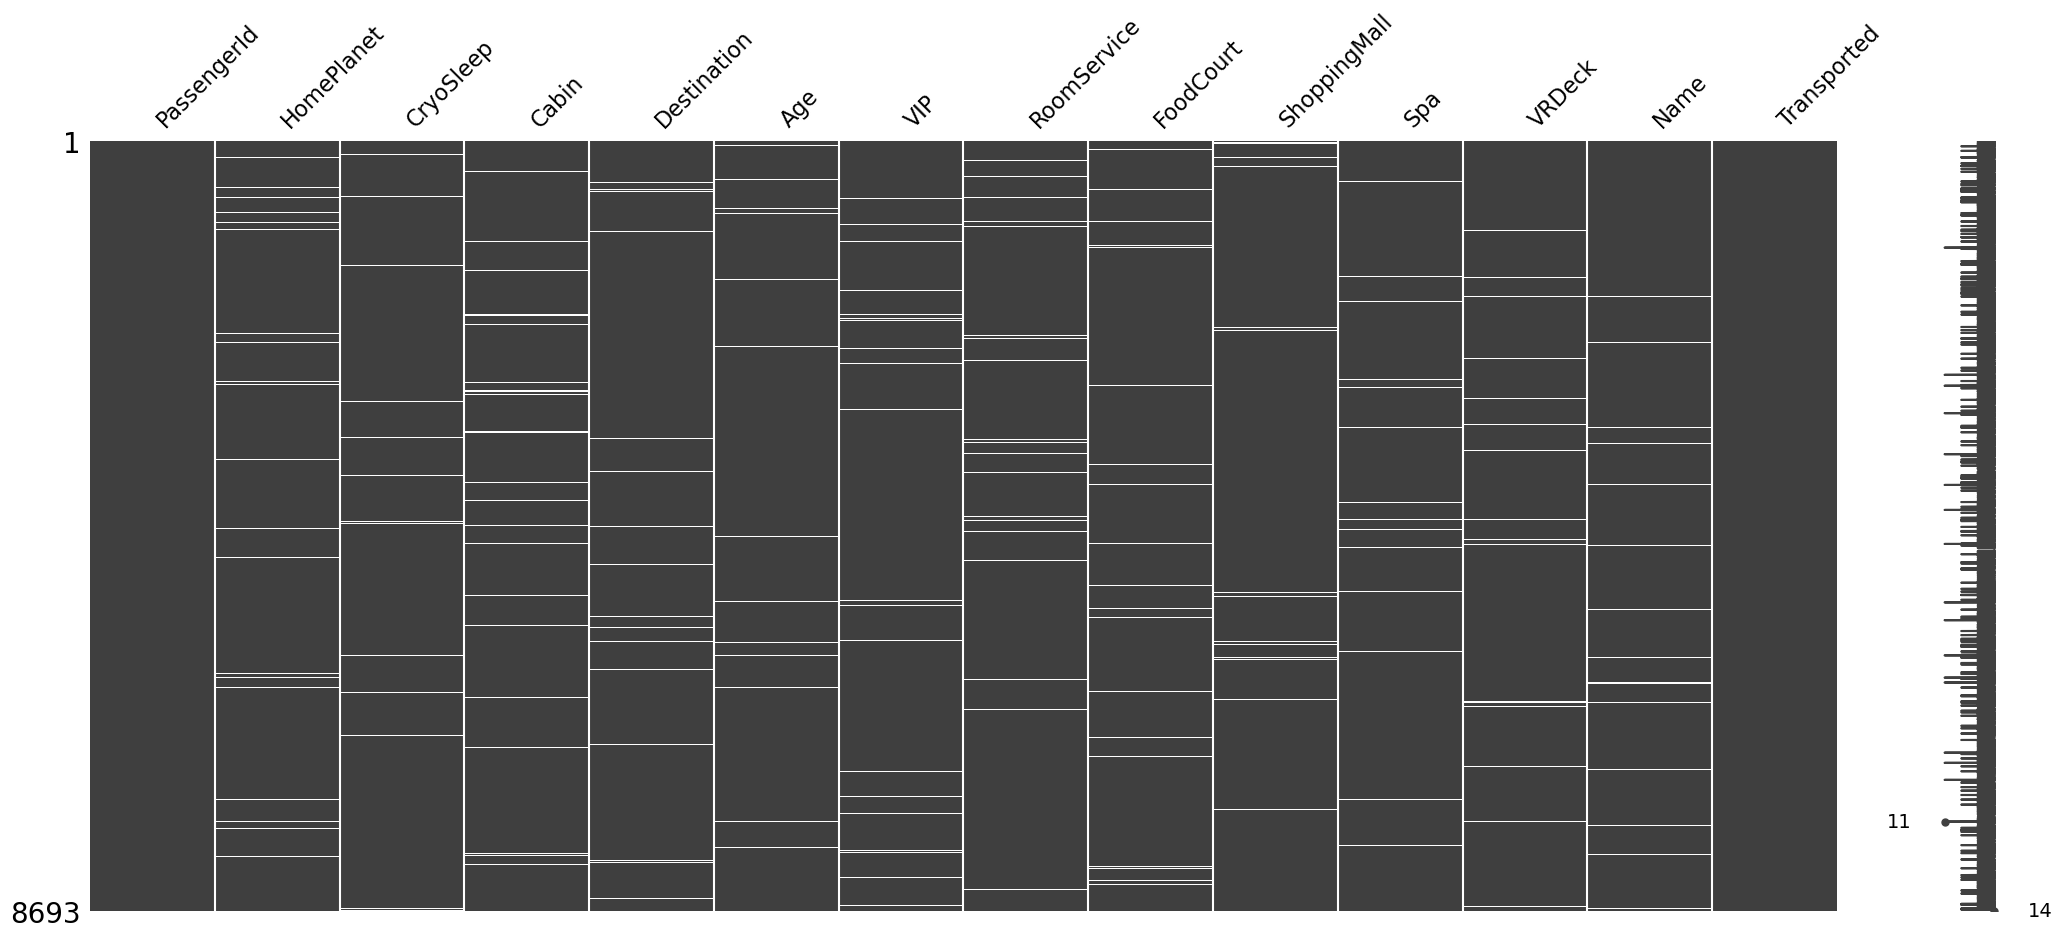

In [95]:
train = pd.read_csv(train_data_path)
test = pd.read_csv(test_data_path)
msno.matrix(train)

In [86]:
print(train.isnull().sum())
test.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64


PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

EDA (데이터 분석) 및 시각화 

In [3]:
train['Transported'].value_counts()  #전체 승객 중 생존자 수

Transported
True     4378
False    4315
Name: count, dtype: int64

In [41]:
train[['Transported', 'VIP']].groupby(['Transported'], as_index=True).sum()

,VIP
Transported,
False,123
True,76


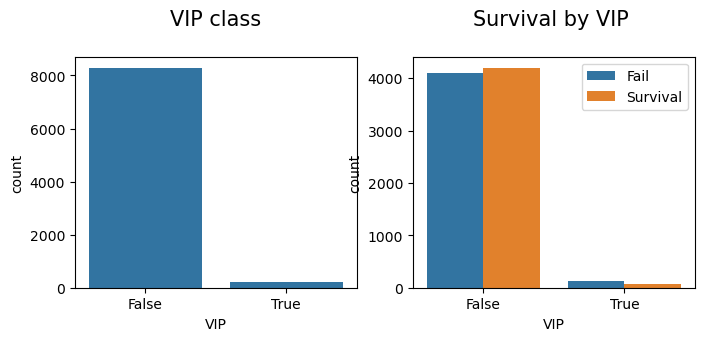

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].set_title("VIP class\n", size=15)
sns.countplot(x="VIP", data=train, ax=axes[0])

axes[1].set_title("Survival by VIP \n", size=15)
sns.countplot(x="VIP", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Survival'])

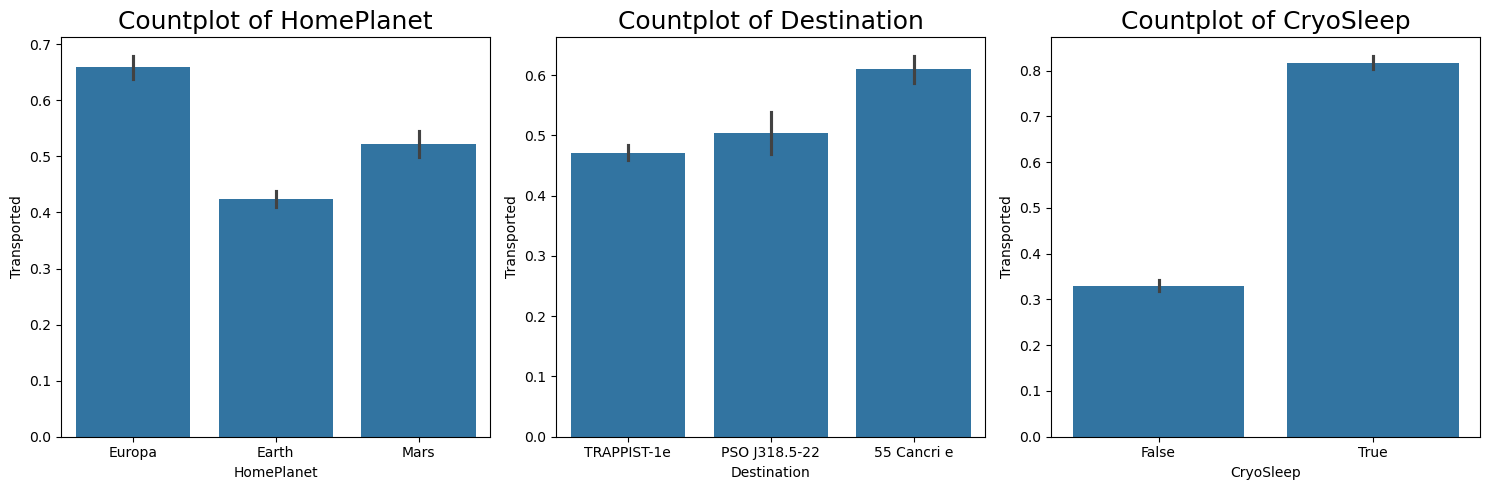

In [50]:
#피처별 생존율 그래프
fig, axes = plt.subplots(1,3, figsize=(15,5))     
cols = ['HomePlanet', 'Destination', 'CryoSleep']

for ax, col in zip(axes.flatten(), cols):
    sns.barplot(x=col, y='Transported', data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':18})
plt.tight_layout()
plt.show()

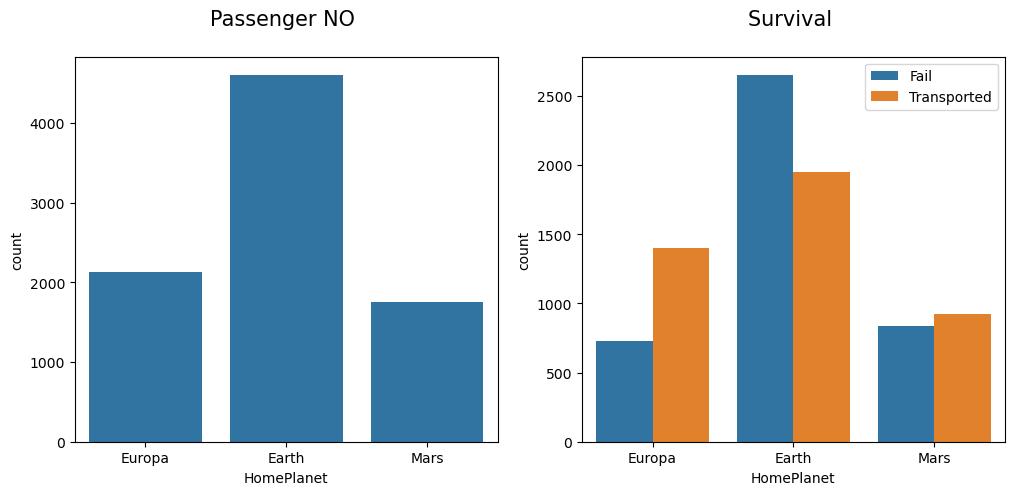

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].set_title("Passenger NO \n", size=15)
sns.countplot(data=train, x='HomePlanet', ax=axes[0])

axes[1].set_title("Survival \n", size=15)
sns.countplot(x="HomePlanet", hue="Transported", data=train, ax=axes[1])
axes[1].legend(labels = ['Fail', 'Transported'])

Text(0.5, 1.0, 'Survival by HomePlanet')

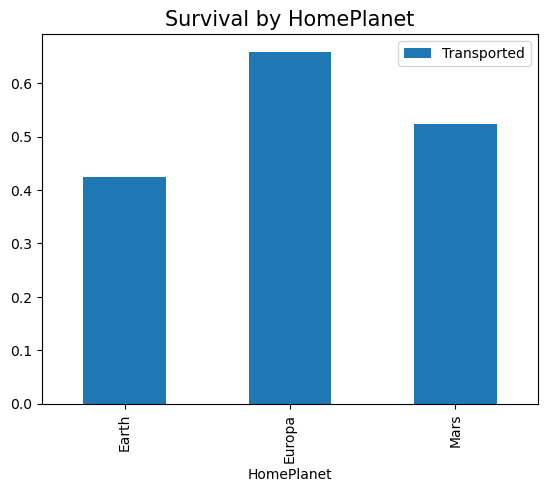

In [62]:
# HomePlanet별 생존률
sur = train[['HomePlanet', 'Transported']].groupby(['HomePlanet']).mean().plot.bar()
sur.set_title('Survival by HomePlanet', size=15)

<Axes: xlabel='Age', ylabel='Density'>

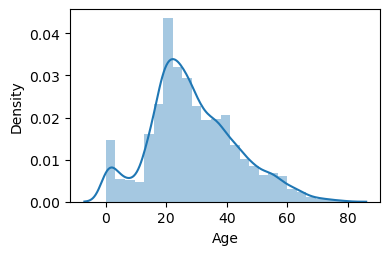

In [77]:
plt.figure(figsize=(4, 2.5))
sns.distplot(train['Age'], bins=25)

<Axes: xlabel='Age', ylabel='Density'>

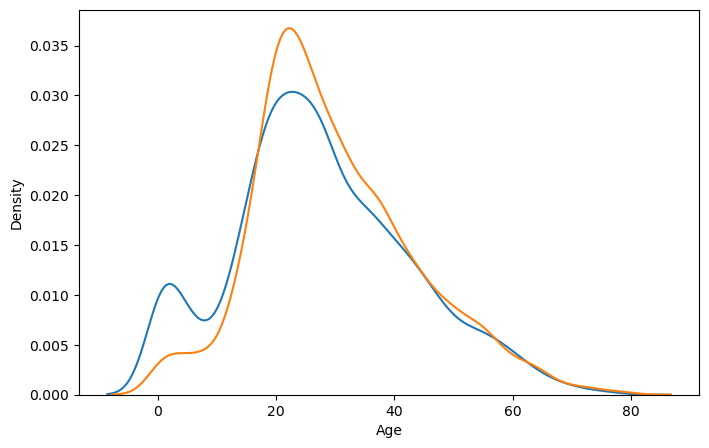

In [78]:
sur = train[train['Transported'] == 1]
dead = train[train['Transported'] == 0]

plt.figure(figsize=(8, 5))
sns.distplot(sur['Age'], bins=25, hist=False)
sns.distplot(dead['Age'], bins=25, hist=False)

데이터 전처리

1. Null 값 채우기
3. 피처 추가:  수
4. 카테고리 타입으로 변경: HomePlanet, Destination
5. 좌우 대칭이 아닌 그래프 데이터들의 정규분포화 작업
6. 불필요한 정보 칼럼 삭제

In [96]:
train_len = len(train)
data = pd.concat([train, test]).reset_index(drop=True)   # 전체 합치기
test_id = data['PassengerId'][train_len:].reset_index(drop=True)  # test의 passenger id 저장

#지출액 데이터 null data 처리
expense_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
data[expense_cols] = data[expense_cols].fillna(0)
data['expense_sum'] = data[expense_cols].sum(axis=1).astype(int)
# data['Active_No_Spend'] = ((data['CryoSleep'] == 0) & (data['expense_sum'] == 0)).astype(int)

#T/F 데이터 null data 처리
TF_cols = ['CryoSleep', 'VIP']
data[TF_cols] = data[TF_cols].fillna(False)
data[TF_cols] = data[TF_cols].replace({True: 1, False: 0})


#출발지, 목적지 데이터 전처리
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

data['HomePlanet'] = data['HomePlanet'].fillna('unknown')
data['HomePlanet'] = le.fit_transform(data['HomePlanet'].astype('category'))

mode_destination = data['Destination'].mode()[0] 
data['Destination'] = data['Destination'].fillna(mode_destination)
data['Destination'] = le.fit_transform(data['Destination'].astype('category'))


#Age 값 처리
mode_age = data['Age'].mode()[0]
data['Age'] = data['Age'].fillna(mode_age)
data.loc[ data['Age'] <= 8, 'Age'] = 0
data.loc[(data['Age'] > 8) & (data['Age'] <= 18), 'Age'] = 1
data.loc[(data['Age'] > 18) & (data['Age'] <= 40), 'Age'] = 2
data.loc[ data['Age'] > 40, 'Age'] = 3
data['Age'] = data['Age'].astype(int)

#Cabin 위치 처리
data['Cabin'] = data['Cabin'].fillna('un/0/un')
data['Cabin1'] = data['Cabin'].apply(lambda x: x.split('/')[0])
data['Cabin2'] = data['Cabin'].apply(lambda x: x.split('/')[1])
data['Cabin3'] = data['Cabin'].apply(lambda x: x.split('/')[2])
cab_cols = ['Cabin1', 'Cabin2', 'Cabin3']
# print(data['Cabin1'].head())
# print(data['Cabin3'].head())
data['Cabin1'] = le.fit_transform(data['Cabin1'].astype('category'))
data['Cabin2'] = data['Cabin2'].astype(int)
data['Cabin3'] = le.fit_transform(data['Cabin3'].astype('category'))

#PassengerID 중 끝자리 가져오기: 혼자 or 일행(가족) 유무
data['passenger_grp'] = data['PassengerId'].apply(lambda x: x.split('_')[1])
data['passenger_grp'] = data['passenger_grp'].astype(int)

# for col in data.columns:
#     if data[col].dtype == 'object':
#         data[col] = data[col].astype('category').cat.codes
# print(data.dtypes)

In [88]:
print(data['Age'].head(200))
data['passenger_grp'].dtype

0      2
1      2
2      3
3      2
4      1
      ..
195    2
196    0
197    0
198    1
199    2
Name: Age, Length: 200, dtype: int64


dtype('int64')

In [97]:
del data['PassengerId']
del data['Name'] 
del data['Cabin'] 
# del data['Cabin2']
del data['ShoppingMall']
del data['Spa']
del data['VRDeck']
# del data['FoodCourt']

train = data.iloc[:train_len]
test  = data.iloc[train_len:]

for col in train.columns:
    if train[col].dtype == 'object':
        train[col] = train[col].astype('category').cat.codes
        test[col]  = test[col].astype('category').cat.codes

print(train.dtypes)

HomePlanet         int64
CryoSleep          int64
Destination        int64
Age                int64
VIP                int64
RoomService      float64
FoodCourt        float64
Transported         int8
expense_sum        int64
Cabin1             int64
Cabin2             int64
Cabin3             int64
passenger_grp      int64
dtype: object


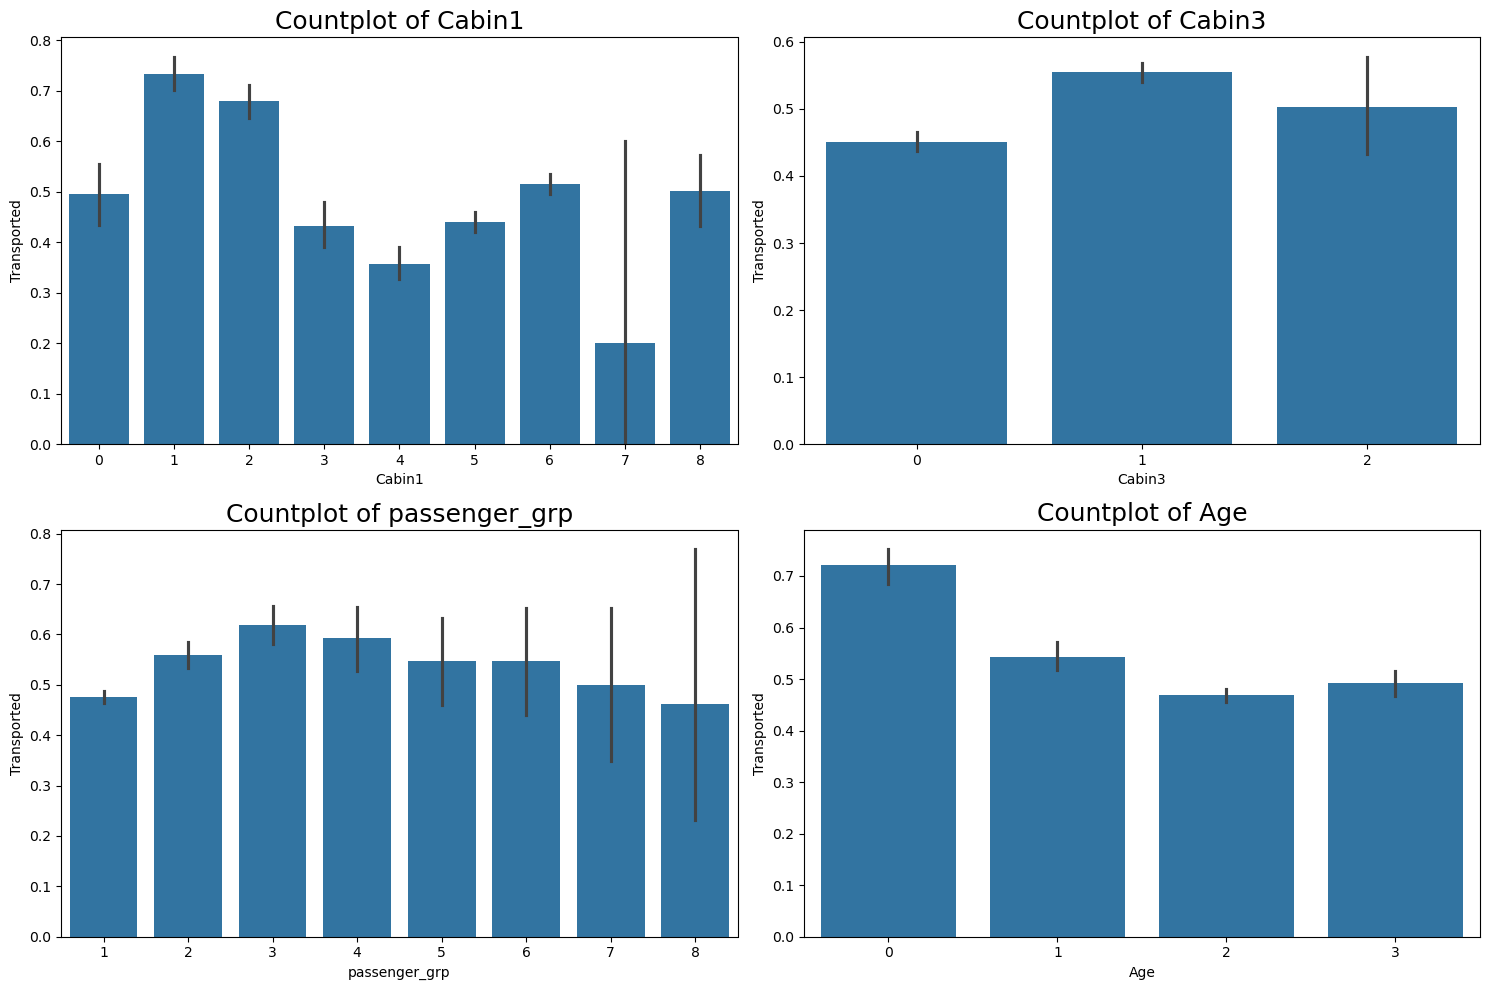

In [90]:
#피처별 생존율 그래프
fig, axes = plt.subplots(2,2, figsize=(15,10))     
cols = ['Cabin1', 'Cabin3', 'passenger_grp', 'Age']

for ax, col in zip(axes.flatten(), cols):
    sns.barplot(x=col, y='Transported', data=train, ax=ax)
    ax.set_title(f'Countplot of {col}', fontdict={'fontsize':18})
plt.tight_layout()
plt.show()

<Axes: >

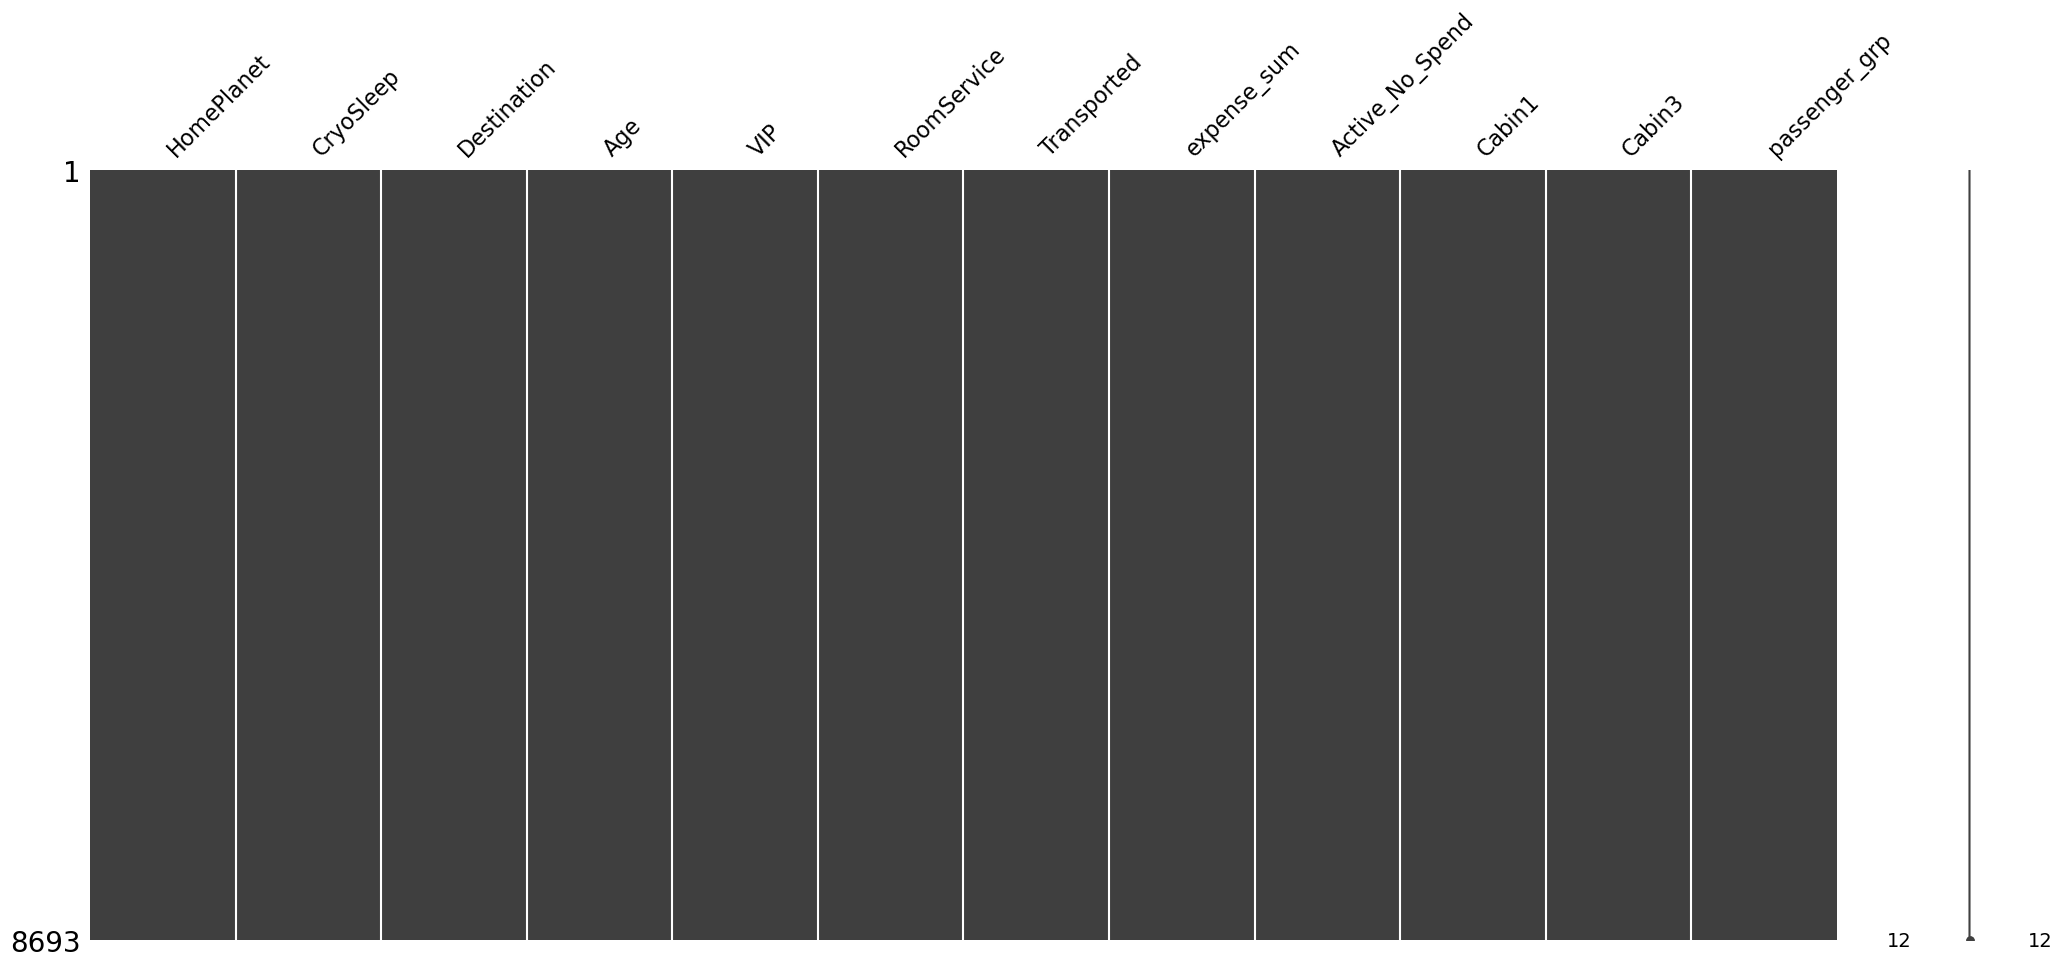

In [64]:
msno.matrix(train)

In [98]:
cor = train.corrwith(train['Transported']).sort_values(ascending=False)
print(cor)

Transported      1.000000
CryoSleep        0.460132
HomePlanet       0.107755
Cabin3           0.093319
passenger_grp    0.066390
FoodCourt        0.045583
VIP             -0.037261
Cabin2          -0.043832
Age             -0.100937
Destination     -0.108152
Cabin1          -0.109925
expense_sum     -0.199514
RoomService     -0.241124
dtype: float64


Text(0.5, 1.0, 'Survival by HomePlanet')

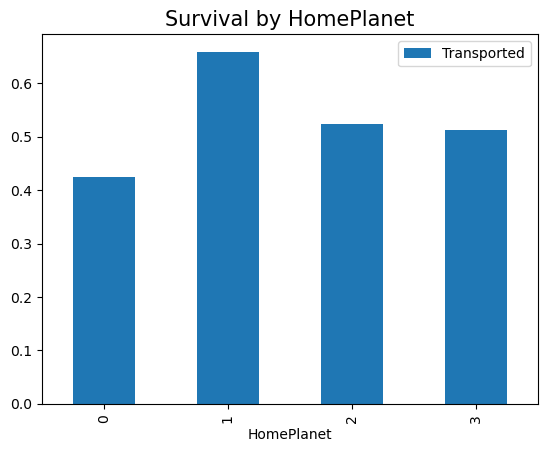

In [59]:
sur = train[['HomePlanet', 'Transported']].groupby(['HomePlanet']).mean().plot.bar()
sur.set_title('Survival by HomePlanet', size=15)

In [99]:
y = train['Transported']
del train['Transported']

y = y.astype(int)

In [101]:
from sklearn.ensemble import RandomForestClassifier 
from sklearn import metrics 
from sklearn.model_selection import train_test_split

y = y.astype(int)
x_tr, x_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)

modl = RandomForestClassifier()
modl.fit(x_tr, y_tr)
predic = modl.predict(x_vld)

print('{}명 중 {:.2f}% 정확도 추론'.format(y_vld.shape[0], 100 * metrics.accuracy_score(predic, y_vld)))

1739명 중 77.80% 정확도 추론


학습 모델 함수 정의
- KNN, GBoost, XGBoost, RandomForest Classfier 모델들을 앙상블로 결합 사용

In [103]:
from sklearn.model_selection import train_test_split
y = y.astype(int)

X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)


from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn import metrics 
from sklearn.metrics import accuracy_score

random_state = 2020


# LGBM 하이퍼파라미터 튜닝 (GridSearchCV + 조기종료) 
lgbm_base = lgb.LGBMClassifier(n_estimators=1000, random_state=2020, verbosity=-1)

param_grid_lgbm = {
    'learning_rate': [0.05, 0.04, 0.02],
    'max_depth': [3, 6, 9],
    'num_leaves': [12, 15, 18],
    # 'min_child_samples': [20, 30]
}

grid_lgbm = GridSearchCV(lgbm_base, param_grid_lgbm, cv=3, scoring='accuracy', n_jobs=-1)
grid_lgbm.fit(
    X_tr, y_tr,
    eval_set=[(X_vld, y_vld)],
    eval_metric='binary_logloss', # 명시적으로 로스 함수 지정
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # LGBMClassifier가 아닌 lgb에서 호출
        lgb.log_evaluation(period=0)
    ]
)

# 최적의 lgbm 모델 추출
lgbm_best = grid_lgbm.best_estimator_
print(f"LGBM 최적 파라미터: {grid_lgbm.best_params_}")


xgboost_best = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=2020,
)

# 최종 Voting 모델 재구성 
knn = KNeighborsClassifier(n_neighbors=5)
gboost = GradientBoostingClassifier(random_state=2020)
rdforest = RandomForestClassifier(random_state=2020)

voting = VotingClassifier(
    estimators=[
        ('knn', knn),
        ('gboost', gboost),
        ('xgboost', xgboost_best), # 튜닝된 모델
        ('lgbm', lgbm_best),       # 튜닝된 모델
        ('rdforest', rdforest)
    ],
    voting='soft'
)

voting.fit(X_tr, y_tr)

prediction_vld = voting.predict(X_vld)
print(f"Voting 검증 정확도: {accuracy_score(y_vld, prediction_vld):.2f}")




Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[148]	valid_0's binary_logloss: 0.422451
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[195]	valid_0's binary_logloss: 0.427267
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[103]	valid_0's binary_logloss: 0.431457
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[118]	valid_0's binary_logloss: 0.425169
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[109]	valid_0's binary_logloss: 0.430773
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[153]	valid_0's binary_logloss: 0.427484
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[153]	valid_0's binary_logloss: 0.423092
Training until validation scores don't i

AttributeError: 'GridSearchCV' object has no attribute 'head'

In [82]:
# 전체 데이터로 다시 학습 (이미 튜닝된 파라미터 사용)
X_all_train = train.drop(['Transported'], axis=1, errors='ignore')
voting.fit(X_all_train, y)

test_features = test.drop(['Transported'], axis=1, errors='ignore')
final_prediction = voting.predict(test_features).astype(bool)


In [83]:

submission = pd.DataFrame({
    'PassengerId': test_id.reset_index(drop=True),
    'Transported': final_prediction.astype(bool)
})

submission.to_csv('~/work/kaggle_kakr_housing/space_titanic/Titanic_submission_v04.csv', index=False)
print(submission.head())

  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01        False
4     0023_01        False


In [67]:
from sklearn.model_selection import train_test_split
y = y.astype(int)

X_tr, X_vld, y_tr, y_vld = train_test_split(train, y, test_size=0.2, random_state=2020)


from sklearn.metrics import mean_squared_error
from sklearn import metrics 
from sklearn.metrics import accuracy_score

from sklearn.ensemble import VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
random_state = 2020

# 모델 설정 
knn      = KNeighborsClassifier(n_neighbors=5)
gboost   = GradientBoostingClassifier(random_state=random_state)
xgboost  = XGBClassifier(random_state=random_state)
lgbm     = LGBMClassifier(random_state=random_state)
rdforest = RandomForestClassifier(random_state=random_state)

voting = VotingClassifier(
    estimators=[
        ('knn',      knn),
        ('gboost',   gboost),
        ('xgboost',  xgboost),
        ('lgbm',     lgbm),
        ('rdforest', rdforest)
    ],
    voting='soft'  # 확률 평균 
)

voting.fit(X_tr, y_tr)
prediction = voting.predict(X_vld)

print(f"Accuracy: {accuracy_score(y_vld, voting.predict(X_vld)):.2f}")

[LightGBM] [Info] Number of positive: 3494, number of negative: 3460
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001247 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 6954, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502445 -> initscore=0.009779
[LightGBM] [Info] Start training from score 0.009779
Accuracy: 0.75


In [68]:
X_train = train.drop(['Transported'], axis=1, errors='ignore') 

voting.fit(X_train, y)

# voting.fit(train, y)
test_rv = test.drop(['Transported'], axis=1)
prediction = voting.predict(test_rv).astype(bool)

print(f"prediction 길이: {len(prediction)}")
print(f"test_id 길이   : {len(test_id)}")

[LightGBM] [Info] Number of positive: 4378, number of negative: 4315
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 548
[LightGBM] [Info] Number of data points in the train set: 8693, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503624 -> initscore=0.014495
[LightGBM] [Info] Start training from score 0.014495
prediction 길이: 4277
test_id 길이   : 4277


제출 파일 작성 

In [69]:

submission = pd.DataFrame({
    'PassengerId': test_id.reset_index(drop=True),
    'Transported': prediction.astype(bool)
})

submission.to_csv('~/work/kaggle_kakr_housing/space_titanic/Titanic_submission_v03.csv', index=False)
print(submission.head())


  PassengerId  Transported
0     0013_01         True
1     0018_01        False
2     0019_01         True
3     0021_01        False
4     0023_01        False


In [ ]:
# print(set(X_train.columns))
# set(test.columns)

In [ ]:
submission.to_csv('submission.csv', index=False)
print(submission.shape)
print(submission['Transported'].value_counts())

In [ ]:
# 검증
from sklearn.metrics import accuracy_score
print(accuracy_score(y_vld, voting.predict(X_vld)))

# test 예측
prediction = voting.predict(test).astype(bool)



In [ ]:
파일 저장용 함수 설정

In [28]:

def save_submission(model, train, y_log, test, model_name, rmsle=best['RMSLE'].round(4)):
    model.fit(train, y_log)
    # prediction = model.predict(test)
    # prediction = np.expm1(prediction)
    prediction = np .expm1(model.predict(test))
    data_dir = '~/work/kaggle_kakr_housing/data'
    submission_path = join(data_dir, 'sample_submission.csv')
    submission = pd.read_csv(submission_path)
    submission['price'] = prediction
    submission_csv_path = '{}/harry_submission_{}_ver_{}.csv'.format(data_dir, model_name, rmsle)
    submission.to_csv(submission_csv_path, index=False)
    print('{} saved!'.format(submission_csv_path))

print(param_gained.head())

    learning_rate  max_depth  n_estimators  num_leaves     score     RMSLE
22           0.05          8          1100          12 -0.025778  0.160556
28           0.05         12          1100          12 -0.025808  0.160649
34           0.05         15          1100          12 -0.025808  0.160649
53           0.04         15          1100          15 -0.025814  0.160666
20           0.05          8           900          12 -0.025818  0.160678


파일 제출 이후 화면 캡쳐